# Assignment 1: Predicting Employee Attrition with Random Forests

Execute cells **top to bottom**. Where you see `# TODO`, add your code.

**Data:** `data/IBM_HR_Employee_Attrition.csv`

**Deliverables produced in this file:**
- Baseline Decision Tree metrics (accuracy, precision, recall)
- Random Forest metrics + side-by-side comparison table
- Feature importance visualization
- Markdown sections for **Key Drivers of Attrition** and **Reflection**

### Download Dependencies
Run this cell once to install all dependencies. These can also be run directly in the terminal if you prefer.


In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
print("Importing required libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

print("✓ All libraries imported successfully!\n")

Importing required libraries...
✓ All libraries imported successfully!



### Step 1: Load the dataset
----------------------------------------------------------------------------
Confirm the CSV can be read and preview the first rows. The following code should output the first 5 rows of the IBM HR data.

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
print("Loading employee attrition dataset...")
df = pd.read_csv('./data/IBM_HR_Employee_Attrition.csv')
print("✓ Dataset loaded successfully!\n")

# Display first few rows to verify load
print("First 5 rows of the dataset:")
print(df.head())

# Display basic info about the dataset
print("\nDataset Information:")
print(df.info())

print("\n" + "="*80)
print("CHECKPOINT: Verify that the dataset loaded correctly and you can see column names")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("="*80 + "\n")

Loading employee attrition dataset...
✓ Dataset loaded successfully!

First 5 rows of the dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical           

### Step 2: Explore and Prepare the Dataset
----------------------------------------------------------------------------
Perform the same kind of exploratory analysis real data scientists do before building a model

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

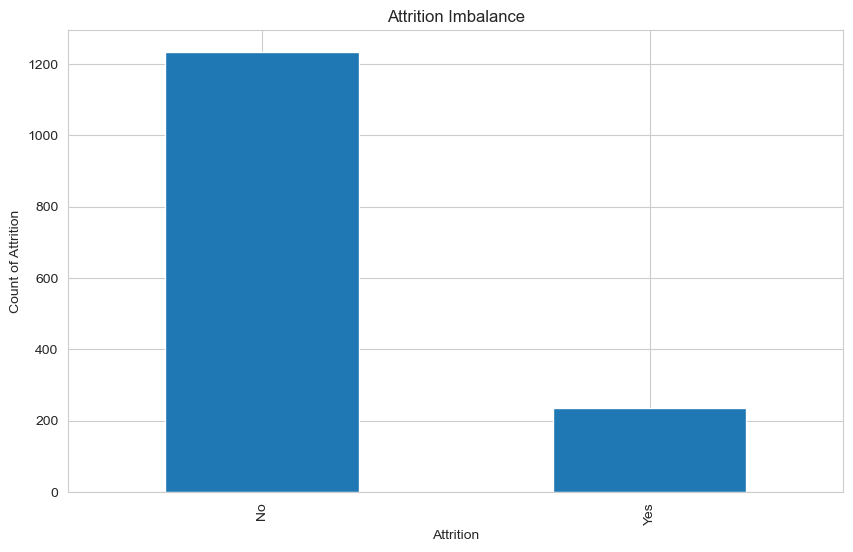


CHECKPOINT: X_cleaned should have all numeric columns, y should contain Attrition values
X_cleaned shape: (1470, 47)
y shape: (1470,)



In [13]:
# Display summary statistics
# TODO: Use df.describe() and df.info() to generate summary statistics for numeric features
df.describe()
df.info()

# Plot attrition counts to see class imbalance
# TODO: Use df['Attrition'].value_counts() and create a visualization using matplotlib to see how imbalanced the dataset is
df['Attrition'].value_counts().plot(kind = "bar")
plt.ylabel("Count of Attrition")
plt.title("Attrition Imbalance")
plt.show()

# Encode categorical variables
# TODO: Use pd.get_dummies() to encode categorical variables
# Store the result in a variable (you'll need this for the next step)
catvar = pd.get_dummies(df, drop_first = True)

# Split features (X) from target (y)
# TODO: Create X_cleaned with all columns except 'Attrition'
# TODO: Create y with just the 'Attrition' column
X_cleaned = catvar.drop("Attrition_Yes", axis = 1)
y = catvar["Attrition_Yes"]


print("\n" + "="*80)
print("CHECKPOINT: X_cleaned should have all numeric columns, y should contain Attrition values")
print(f"X_cleaned shape: {X_cleaned.shape if X_cleaned is not None else 'Not yet defined'}")
print(f"y shape: {y.shape if y is not None else 'Not yet defined'}")
print("="*80 + "\n")

### Step 3: Train a Baseline Decision Tree Model
----------------------------------------------------------------------------
Build a baseline decision tree for comparison

In [14]:
# Split data into training and test sets
# TODO: Use train_test_split with test_size=0.2, random_state=42, stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y, 
    test_size = 0.2,
    random_state = 42, 
    stratify = y
)# Replace with train_test_split()

# Train a decision tree classifier
# TODO: Initialize DecisionTreeClassifier(random_state=42)
dt_model = DecisionTreeClassifier(random_state = 42)  # Replace with DecisionTreeClassifier

# TODO: Fit the model on training data
dt_model.fit(X_train, y_train)

# Make predictions on test set
# TODO: Use dt_model.predict() on X_test
dt_predictions = dt_model.predict(X_test)  # Replace with predictions

# Calculate evaluation metrics
# TODO: Calculate accuracy, precision, and recall for the decision tree
dt_accuracy = accuracy_score(y_test, dt_predictions)  # Replace with accuracy_score()
dt_precision = precision_score(y_test, dt_predictions)  # Replace with precision_score()
dt_recall = recall_score(y_test, dt_predictions)  # Replace with recall_score()

# Print results
print("\n" + "="*80)
print("BASELINE DECISION TREE RESULTS")
print("="*80)
# TODO: Print accuracy, precision, and recall with clear labels
print(f"Accuracy: {dt_accuracy if dt_accuracy is not None else 'Not yet calculated'}")
print(f"Precision: {dt_precision if dt_precision is not None else 'Not yet calculated'}")
print(f"Recall: {dt_recall if dt_recall is not None else 'Not yet calculated'}")
print("="*80 + "\n")


BASELINE DECISION TREE RESULTS
Accuracy: 0.8027210884353742
Precision: 0.3877551020408163
Recall: 0.40425531914893614



### Step 4: Build and Evaluate a Random Forest Model
----------------------------------------------------------------------------
Move beyond a single tree to a more powerful ensemble model

In [15]:
# Move beyond a single tree to a more powerful ensemble model

# Train a random forest classifier
# TODO: Initialize and train a RandomForestClassifier with these parameters:
# n_estimators=200, max_depth=None, min_samples_split=10, min_samples_leaf=2,
# max_features='sqrt', class_weight='balanced', random_state=42
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = None,
    min_samples_split = 10,
    min_samples_leaf = 2,
    max_features = "sqrt",
    class_weight = "balanced",
    random_state = 42
)# Replace with trained RandomForestClassifier

# Make predictions using probability threshold
# TODO: Use rf_model.predict_proba() to get probabilities for the positive class
# TODO: Apply a threshold of 0.35 to convert probabilities to predictions
# (rf_probabilities >= 0.35).astype(int)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_predictions = (rf_probs >= 0.35).astype(int)  # Replace with threshold-adjusted predictions

# Calculate evaluation metrics
# TODO: Calculate accuracy, precision, and recall for the random forest
rf_accuracy = accuracy_score(y_test, rf_predictions)  # Replace with accuracy_score()
rf_precision = precision_score(y_test, rf_predictions)  # Replace with precision_score()
rf_recall = recall_score(y_test, rf_predictions)  # Replace with recall_score()

# Print results
print("\n" + "="*80)
print("RANDOM FOREST RESULTS")
print("="*80)
print(f"Accuracy: {rf_accuracy if rf_accuracy is not None else 'Not yet calculated'}")
print(f"Precision: {rf_precision if rf_precision is not None else 'Not yet calculated'}")
print(f"Recall: {rf_recall if rf_recall is not None else 'Not yet calculated'}")
print("="*80 + "\n")

# Create comparison table
# TODO: Create a pandas DataFrame comparing both models side-by-side
# Columns: Model, Accuracy, Precision, Recall
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall]
})# Replace with DataFrame

# TODO: Display the comparison table
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
# Display table here
print("="*80 + "\n")


RANDOM FOREST RESULTS
Accuracy: 0.7959183673469388
Precision: 0.4
Recall: 0.5531914893617021


MODEL COMPARISON



### Step 5: Interpret Feature Importances
----------------------------------------------------------------------------
Turn model results into actionable insights for HR

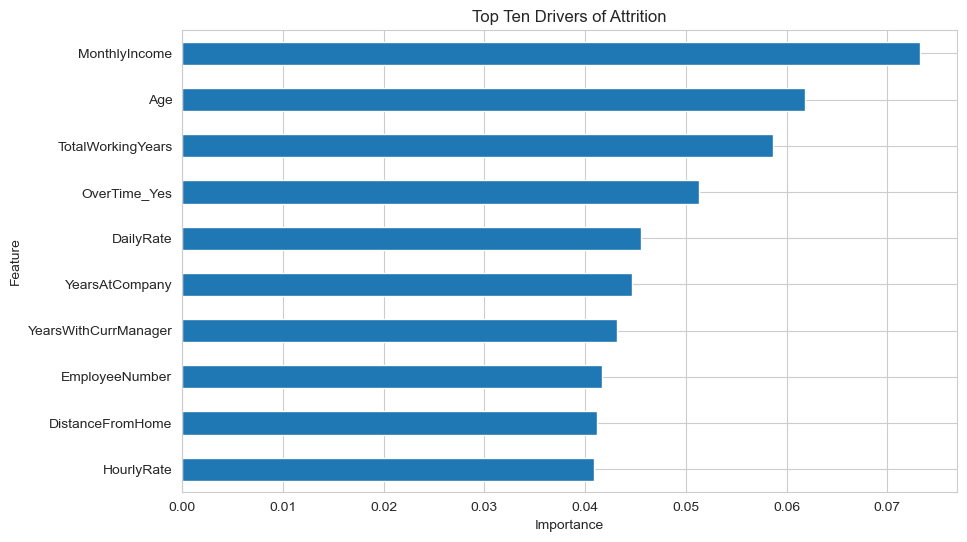


KEY DRIVERS OF ATTRITION


In [16]:
# Extract feature importances
# TODO: Get feature_importances_ from rf_model and create a pandas Series
# with feature names as index
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index = X_cleaned.columns
)# Replace with Series of importances

# TODO: Sort feature importances in descending order
desc = feature_importances.sort_values(ascending = False)

# TODO: Get top 10 most important features
top_10_features = desc.head(10)  # Replace with top 10

# Visualize top 10 feature importances
# TODO: Create a horizontal bar plot of the top 10 features
# Use plt.barh() or top_10_features.plot(kind='barh')
top_10_features.sort_values().plot(kind = "barh")
plt.title("Top Ten Drivers of Attrition")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("\n" + "="*80)
print("KEY DRIVERS OF ATTRITION")
print("="*80)

#### Key Drivers of Attrition

- Monthly income is the strongest factor in determining whether an employee will stay
- Age of the employee is the next strongest factor in determining if they will stay
- Total number of years they have worked is the 3rd leading factor in determining if they will stay
- They generally lose employees who have worked a long time and are close to retirement or those who they do not pay enough

### Step 6: Reflection (150-200 words)
----------------------------------------------------------------------------
Write a 150-200 word reflection addressing:
- How the random forest improved upon the decision tree baseline
- When ensemble methods are worth the added complexity
- How these modeling skills connect to your final project

The baseline model relied on a single decision tree, while the updated approach combines many individual trees into a random forest, which is an ensemble method. By averaging predictions across multiple trees, the random forest reduces overfitting and produces predictions that generalize better to unseen data. Adjusting the probability threshold also improved recall, which is especially important for an imbalanced attrition dataset where failing to identify employees at risk can be costly. In these situations, missed predictions may lead to unnecessary turnover and increased organizational expenses. Ensemble methods are worth the additional complexity because they capture nonlinear relationships and interactions between variables more effectively than simpler models. They also generate insights that a single decision tree cannot reveal on its own. For the final course project, being able to train, evaluate, and interpret ensemble models like random forests will be critical for building reliable, real-world data science solutions in practice.

### Step 7: Push to GitHub
----------------------------------------------------------------------------
Once complete, save and push your work:
1. Save this file
2. Run in terminal:
```sh
git add .
git commit -m 'completed employee attrition assignment'
git push
```